In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir('/workspaces/hantavirus-outbreak-analysis')

dict_df = pd.read_csv('data/data_dictionary.csv')
print("Data Dictionary shape:", dict_df.shape)
dict_df.head()

master = pd.read_csv('data/hantavirus_master.csv')
print("\nMaster table shape:", master.shape)
master.head()

Data Dictionary shape: (32, 4)

Master table shape: (109, 15)


,iso3,country,who_region,syndrome,total_cases,total_deaths,avg_cfr,years_reporting,first_year,last_year,virus_strain,clinical_cfr,avg_hospital_days,avg_incubation,icu_rate
0,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Andes,0.3053,10.723077,13.928994,0.518343
1,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Araraquara,0.3153,10.425676,17.288288,0.500000
2,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Choclo,0.2348,10.168116,17.782609,0.492754
3,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Laguna Negra,0.2639,10.150215,13.896996,0.482833
4,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Sin Nombre,0.2692,9.730769,17.580769,0.446154


In [7]:
# Load master dataset
master = pd.read_csv('data/hantavirus_master.csv')
print(master.shape)
master.head()

(109, 15)


,iso3,country,who_region,syndrome,total_cases,total_deaths,avg_cfr,years_reporting,first_year,last_year,virus_strain,clinical_cfr,avg_hospital_days,avg_incubation,icu_rate
0,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Andes,0.3053,10.723077,13.928994,0.518343
1,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Araraquara,0.3153,10.425676,17.288288,0.500000
2,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Choclo,0.2348,10.168116,17.782609,0.492754
3,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Laguna Negra,0.2639,10.150215,13.896996,0.482833
4,ARG,Argentina,AMRO,HPS,2943,842,0.288684,31,1995,2025,Sin Nombre,0.2692,9.730769,17.580769,0.446154


In [8]:
# 1. Check columns and data types
print(master.dtypes)

# 2. Check for missing values
print(master.isnull().sum())

# 3. Get basic statistics for numeric columns
master.describe()

# 4. Check for duplicate rows
print(f"Duplicate rows: {master.duplicated().sum()}")

iso3                     str
country                  str
who_region               str
syndrome                 str
total_cases            int64
total_deaths           int64
avg_cfr              float64
years_reporting        int64
first_year             int64
last_year              int64
virus_strain             str
clinical_cfr         float64
avg_hospital_days    float64
avg_incubation       float64
icu_rate             float64
dtype: object
iso3                 0
country              0
who_region           0
syndrome             0
total_cases          0
total_deaths         0
avg_cfr              0
years_reporting      0
first_year           0
last_year            0
virus_strain         0
clinical_cfr         0
avg_hospital_days    0
avg_incubation       0
icu_rate             0
dtype: int64
Duplicate rows: 0


In [9]:
clinical = pd.read_csv('data/hantavirus_clinical.csv')
environmental = pd.read_csv('data/hantavirus_environmental.csv')
monthly = pd.read_csv('data/hantavirus_monthly_trends.csv')
country_yearly = pd.read_csv('data/hantavirus_country_yearly.csv')
outbreaks = pd.read_csv('data/hantavirus_outbreaks.csv')
strains = pd.read_csv('data/hantavirus_virus_strains.csv')

In [10]:
print("clinical:", clinical.shape)
print("environmental:", environmental.shape)
print("monthly:", monthly.shape)
print("country_yearly:", country_yearly.shape)
print("outbreaks:", outbreaks.shape)
print("strains:", strains.shape)

clinical: (7538, 29)
environmental: (896, 15)
monthly: (924, 5)
country_yearly: (939, 15)
outbreaks: (20, 10)
strains: (10, 12)


In [14]:
# Unique countries and virus strains
print("Number of unique countries:", master['country'].nunique())
print("\nCountries:\n", master['country'].unique())

print("\nVirus strains:\n", master['virus_strain'].unique())

print("\nSyndromes:\n", master['syndrome'].unique())

Number of unique countries: 25

Countries:
 <StringArray>
[     'Argentina',        'Belgium',       'Bulgaria',        'Bolivia',
         'Brazil',         'Canada',          'Chile',          'China',
        'Germany',        'Finland',         'France', 'United Kingdom',
         'Greece',        'Croatia',          'Japan',    'South Korea',
         'Norway',         'Panama',       'Paraguay',         'Russia',
      'Singapore',       'Slovenia',         'Sweden',        'Uruguay',
  'United States']
Length: 25, dtype: str

Virus strains:
 <StringArray>
[       'Andes',   'Araraquara',       'Choclo', 'Laguna Negra',
   'Sin Nombre',      'Dobrava',      'Hantaan',      'Puumala',
        'Seoul']
Length: 9, dtype: str

Syndromes:
 <StringArray>
['HPS', 'HFRS']
Length: 2, dtype: str


In [15]:
# Cases vs deaths
inconsistent = master[master['total_deaths'] > master['total_cases']]
print(f"Rows with deaths > cases: {len(inconsistent)}")
if len(inconsistent) > 0:
    print(inconsistent[['country', 'total_cases', 'total_deaths']])

# Year range check
invalid_years = master[master['first_year'] > master['last_year']]
print(f"Rows with first_year > last_year: {len(invalid_years)}")

Rows with deaths > cases: 0
Rows with first_year > last_year: 0


In [16]:
# Use boxplots or IQR method
numeric_cols = ['total_cases', 'total_deaths', 'avg_cfr', 'clinical_cfr', 
                'avg_hospital_days', 'avg_incubation', 'icu_rate']

for col in numeric_cols:
    Q1 = master[col].quantile(0.25)
    Q3 = master[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = master[(master[col] < lower) | (master[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

total_cases: 20 outliers
total_deaths: 12 outliers
avg_cfr: 0 outliers
clinical_cfr: 0 outliers
avg_hospital_days: 0 outliers
avg_incubation: 0 outliers
icu_rate: 0 outliers


In [17]:
# Mortality per 1000 cases
master['deaths_per_1000'] = (master['total_deaths'] / master['total_cases']) * 1000

# Total cases in millions (if needed for scaling)
master['cases_millions'] = master['total_cases'] / 1_000_000

# Duration of reporting (years)
master['reporting_duration'] = master['last_year'] - master['first_year']

# Check distribution
master[['deaths_per_1000', 'reporting_duration']].head()

,deaths_per_1000,reporting_duration
0,286.102616,30
1,286.102616,30
2,286.102616,30
3,286.102616,30
4,286.102616,30


In [18]:
master.to_csv('data/master_cleaned.csv', index=False)
print("Cleaned master saved to data/master_cleaned.csv")

Cleaned master saved to data/master_cleaned.csv


Top 10 countries by CFR (%):
           country   avg_cfr
18          Brazil  0.355667
13         Bolivia  0.353948
104  United States  0.350758
28           Chile  0.318645
0        Argentina  0.288684
78        Paraguay  0.283190
99         Uruguay  0.187823
73          Panama  0.179733
23          Canada  0.179681
65     South Korea  0.049589


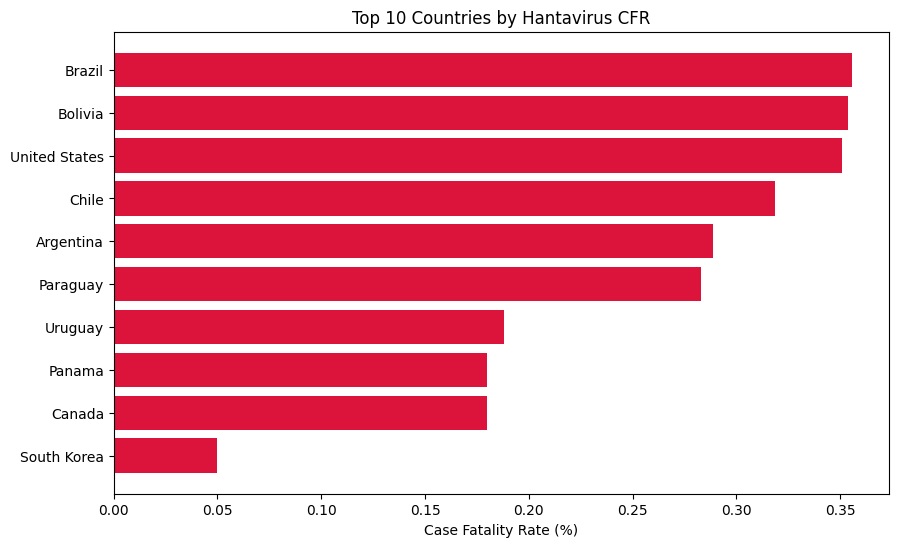

In [19]:
# Sort countries by average CFR (already in master)
cfr_by_country = master[['country', 'avg_cfr']].drop_duplicates().sort_values('avg_cfr', ascending=False)
print("Top 10 countries by CFR (%):")
print(cfr_by_country.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(cfr_by_country['country'].head(10), cfr_by_country['avg_cfr'].head(10), color='crimson')
plt.xlabel('Case Fatality Rate (%)')
plt.title('Top 10 Countries by Hantavirus CFR')
plt.gca().invert_yaxis()
plt.show()

syndrome
HFRS    0.01003
HPS     0.27757
Name: avg_cfr, dtype: float64


<Figure size 800x500 with 0 Axes>

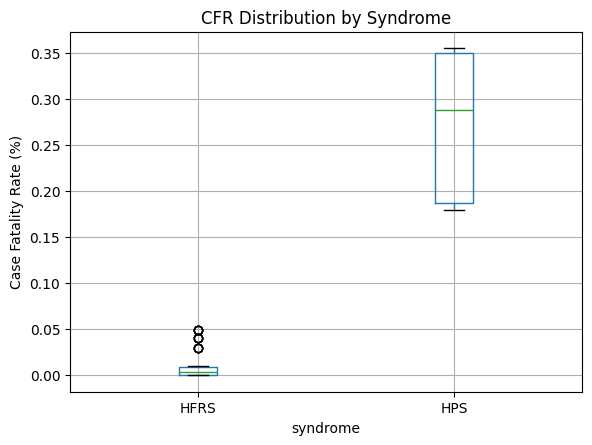

In [20]:
# Group by syndrome
syndrome_cfr = master.groupby('syndrome')['avg_cfr'].mean()
print(syndrome_cfr)

# Boxplot comparison
plt.figure(figsize=(8,5))
master.boxplot(column='avg_cfr', by='syndrome')
plt.title('CFR Distribution by Syndrome')
plt.suptitle('')
plt.ylabel('Case Fatality Rate (%)')
plt.show()

virus_strain
Araraquara      0.3153
Andes           0.3053
Sin Nombre      0.2692
Laguna Negra    0.2639
Choclo          0.2348
Dobrava         0.0846
Hantaan         0.0631
Seoul           0.0238
Puumala         0.0063
Name: clinical_cfr, dtype: float64


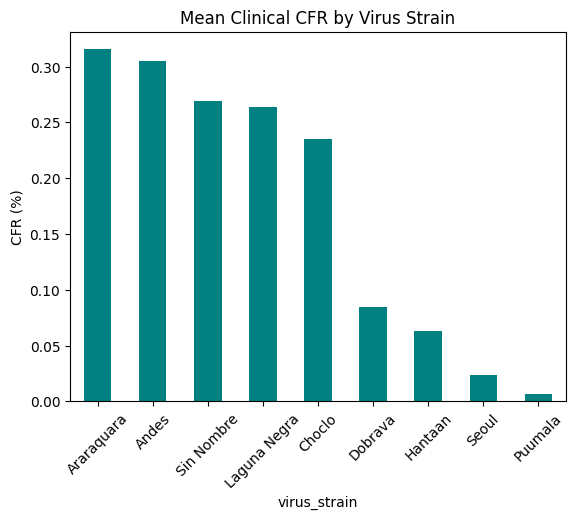

In [21]:
strain_cfr = master.groupby('virus_strain')['clinical_cfr'].mean().sort_values(ascending=False)
print(strain_cfr)

strain_cfr.plot(kind='bar', color='teal')
plt.title('Mean Clinical CFR by Virus Strain')
plt.ylabel('CFR (%)')
plt.xticks(rotation=45)
plt.show()

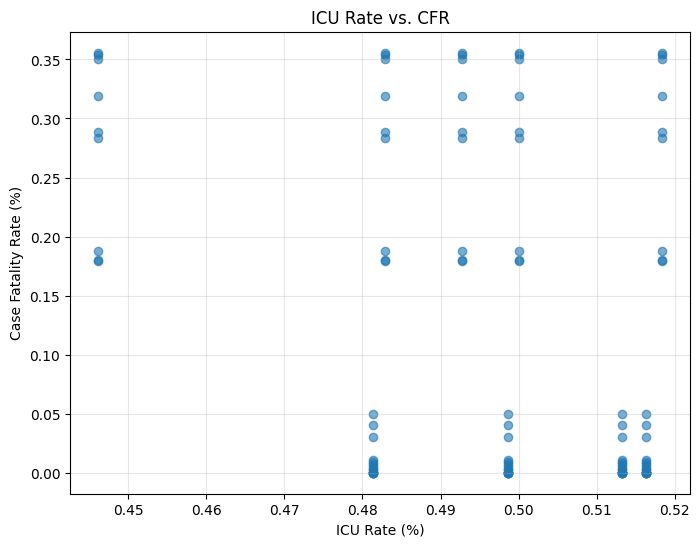

Correlation: -0.33


In [22]:
plt.figure(figsize=(8,6))
plt.scatter(master['icu_rate'], master['avg_cfr'], alpha=0.6)
plt.xlabel('ICU Rate (%)')
plt.ylabel('Case Fatality Rate (%)')
plt.title('ICU Rate vs. CFR')
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
correlation = master[['icu_rate', 'avg_cfr']].corr()
print(f"Correlation: {correlation.iloc[0,1]:.2f}")

## Key findings from EDA

1. HPS (hantavirus pulmonary syndrome) has ~28x higher CFR (27.8%) than HFRS (1.0%).
2. South American countries (Brazil, Bolivia, Chile, Argentina) have the highest CFR (>28%).
3. The most deadly strains are Araraquara (31.5%), Andes (30.5%), and Sin Nombre (26.9%).
4. Higher ICU admission rates correlate with lower CFR (r = -0.33), suggesting supportive care saves lives.

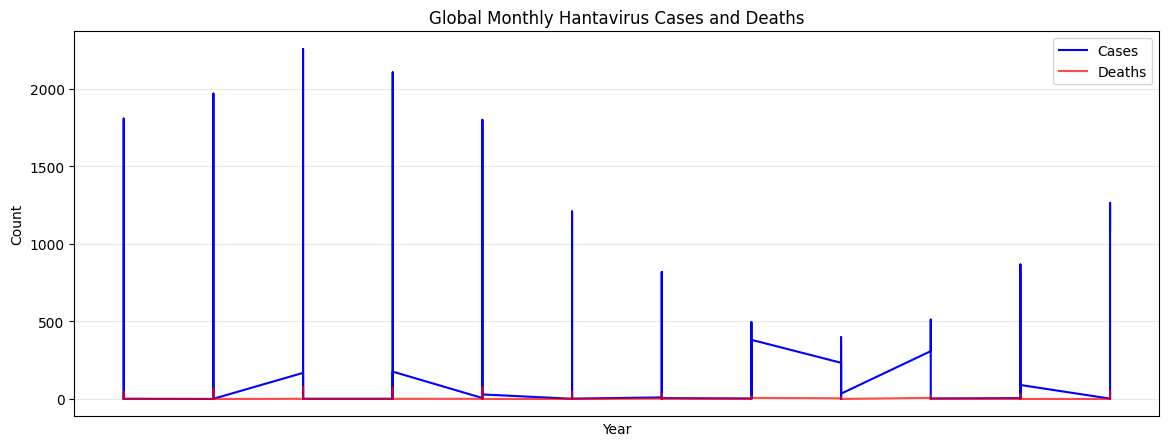

In [24]:
monthly = pd.read_csv('data/hantavirus_monthly_trends.csv')
monthly['month'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values('month')

plt.figure(figsize=(14,5))
plt.plot(monthly['month'], monthly['cases'], label='Cases', color='blue')
plt.plot(monthly['month'], monthly['deaths'], label='Deaths', color='red', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Global Monthly Hantavirus Cases and Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('visualizations/monthly_trends_global.png', dpi=300)
plt.show()